In [58]:
# 安装额外的库
!pip install statsmodels filterpy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import json
import os

# 新增导入
from statsmodels.tsa.seasonal import seasonal_decompose
from filterpy.kalman import KalmanFilter # filterpy库中的KalmanFilter

# 设置设备 (GPU 或 CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- Environment Setup ---")
print(f"Using device: {device}")
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"CUDA available. GPU: {torch.cuda.get_device_name(0)}")
    print(f"PyTorch built with CUDA version: {torch.version.cuda}")
else:
    print("CUDA not available. Running on CPU.")

import sympy
print(f"Sympy Version: {sympy.__version__}") # 确保 sympy 已正确加载
print(f"--- Setup Complete ---")

--- Environment Setup ---
Using device: cuda
PyTorch Version: 2.5.1+cu124
CUDA available. GPU: Tesla T4
PyTorch built with CUDA version: 12.4
Sympy Version: 1.13.1
--- Setup Complete ---



--- Data Loading, Initial Labeling, and Seasonal Decomposition ---
Successfully loaded data from: /content/art_load_balancer_spikes.csv
Timestamp column processed and set as index.
Initial label processing complete. Processed 1 anomaly window(s).
Total data points initially marked as anomalous in data_df: 403

Starting seasonal decomposition with period = 60...
Seasonal decomposition complete.


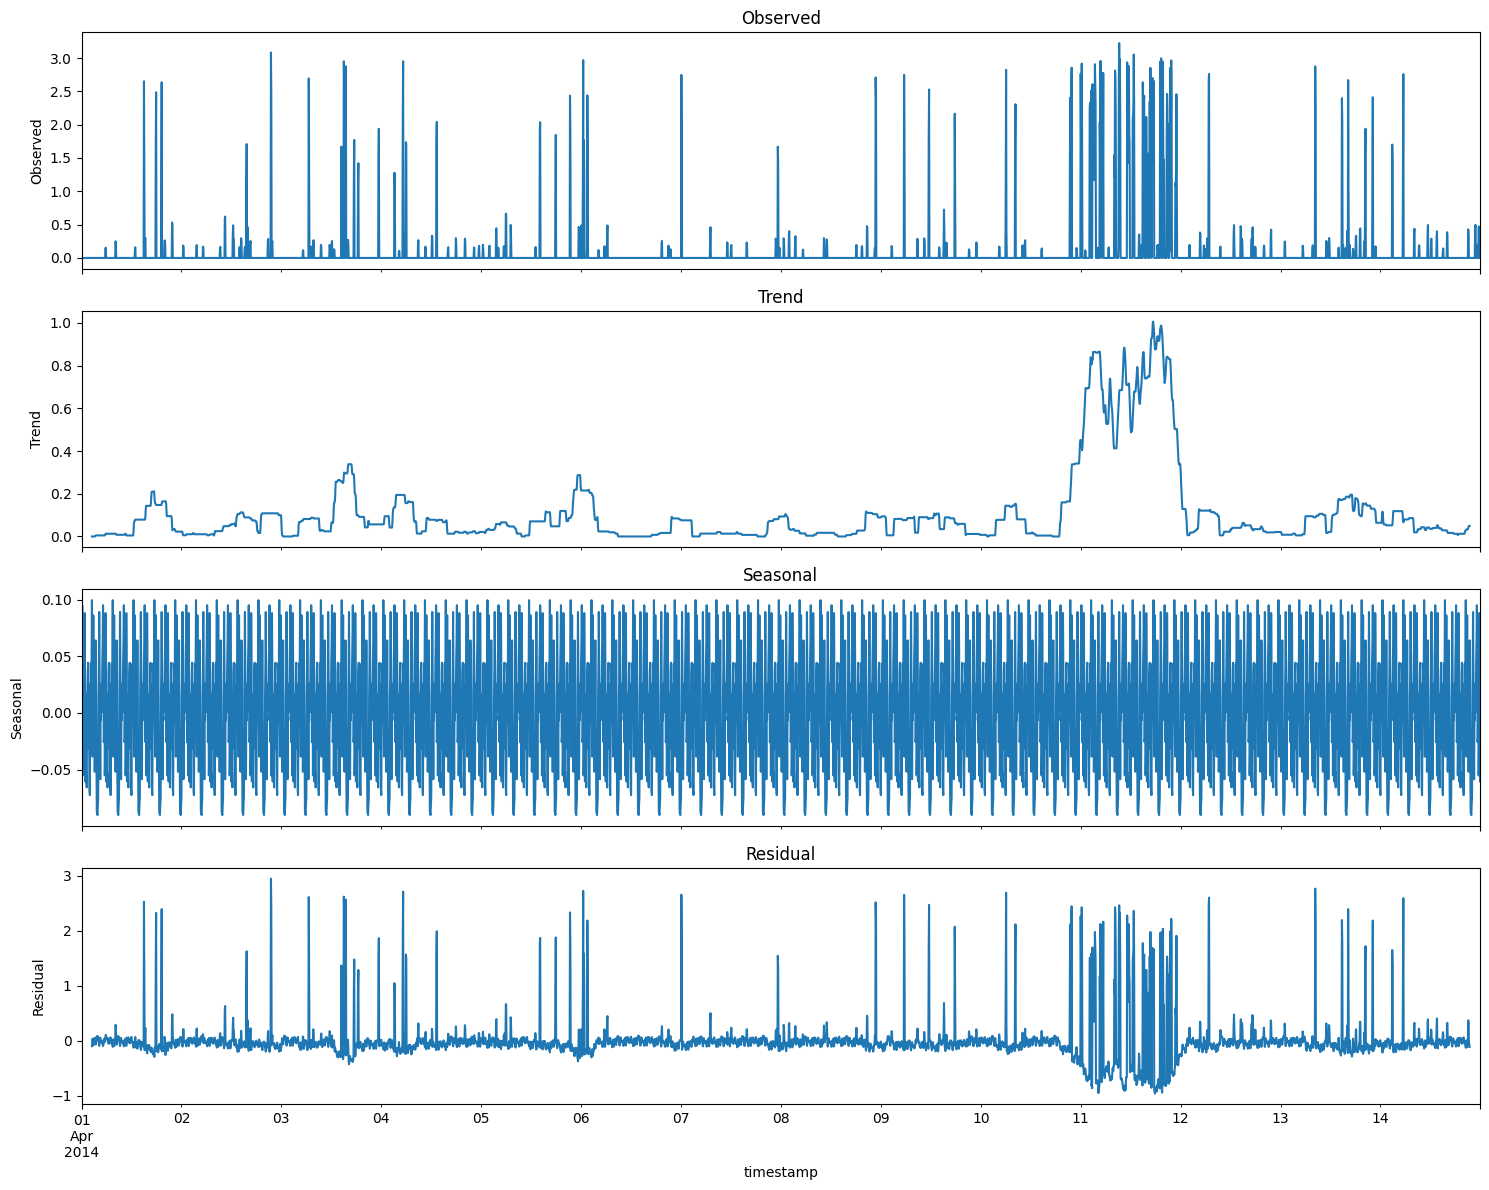

Using residual component for Kalman filtering. Length: 4032, NaNs: 60
--- Data Loading, Initial Labeling, and Seasonal Decomposition Complete ---


In [59]:
print(f"\n--- Data Loading, Initial Labeling, and Seasonal Decomposition ---")
DATA_FILE_COLAB_PATH = '/content/art_load_balancer_spikes.csv'
LABEL_FILE_COLAB_PATH = '/content/combined_windows.json'
JSON_KEY_FOR_LABELS = 'artificialWithAnomaly/art_load_balancer_spikes.csv'

data_df = None # 初始化
try:
    data_df = pd.read_csv(DATA_FILE_COLAB_PATH)
    print(f"Successfully loaded data from: {DATA_FILE_COLAB_PATH}")
    data_df['timestamp'] = pd.to_datetime(data_df['timestamp'])
    data_df = data_df.set_index('timestamp')
    print("Timestamp column processed and set as index.")
except Exception as e:
    print(f"Error during data loading or initial timestamp processing: {e}")
    # raise # 如果希望在错误时停止，可以取消注释这行

# 1. 初始异常标签标记 (在原始 data_df 上)
if data_df is not None:
    data_df['is_anomaly'] = 0
    parsed_anomaly_windows_count_initial = 0
    try:
        with open(LABEL_FILE_COLAB_PATH, 'r') as f:
            all_labels_json = json.load(f)
        raw_anomaly_windows_list = all_labels_json.get(JSON_KEY_FOR_LABELS, [])
        if raw_anomaly_windows_list:
            for window_event in raw_anomaly_windows_list:
                if isinstance(window_event, list) and len(window_event) == 2:
                    try:
                        start_ts = pd.to_datetime(window_event[0])
                        end_ts = pd.to_datetime(window_event[1])
                        anomalous_points_mask = (data_df.index >= start_ts) & (data_df.index <= end_ts)
                        data_df.loc[anomalous_points_mask, 'is_anomaly'] = 1
                        if anomalous_points_mask.sum() > 0:
                            parsed_anomaly_windows_count_initial += 1
                    except Exception as e_win:
                        print(f"  Warning: Could not process window event {window_event} for initial labeling: {e_win}")
            print(f"Initial label processing complete. Processed {parsed_anomaly_windows_count_initial} anomaly window(s).")
            print(f"Total data points initially marked as anomalous in data_df: {data_df['is_anomaly'].sum()}")
        else:
            print(f"No anomaly windows found for key '{JSON_KEY_FOR_LABELS}' for initial labeling.")
    except Exception as e_label:
        print(f"An error occurred during initial label processing: {e_label}")

# 2. 季节性分解
if data_df is not None and 'value' in data_df.columns:
    # NAB art_load_balancer_spikes.csv 数据是每5分钟一个点
    # 日周期 = 24小时 * 12个点/小时 = 288个点
    # 用户示例 period=60 (5小时周期 = 5 * 12 = 60个点)
    # 我们选择一个合适的周期，例如日周期
    decomposition_period = 60 #288
    print(f"\nStarting seasonal decomposition with period = {decomposition_period}...")

    # 确保数据足够长以进行分解，并且没有太多NaN值（此数据集通常没有）
    if len(data_df['value']) > 2 * decomposition_period and not data_df['value'].isnull().all():
        # 如果原始数据中有NaN，seasonal_decompose可能会出问题或结果不佳，需要先处理
        # 对于这个特定的数据集，我们假设'value'列是完整的
        decomposition = seasonal_decompose(data_df['value'], model='additive', period=decomposition_period)

        trend_component = decomposition.trend
        seasonal_component = decomposition.seasonal
        residual_component = decomposition.resid # 我们主要关注残差

        print("Seasonal decomposition complete.")

        # 可选：绘制分解图
        fig_decomp, axes_decomp = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
        decomposition.observed.plot(ax=axes_decomp[0], legend=False, title='Observed')
        axes_decomp[0].set_ylabel('Observed')
        decomposition.trend.plot(ax=axes_decomp[1], legend=False, title='Trend')
        axes_decomp[1].set_ylabel('Trend')
        decomposition.seasonal.plot(ax=axes_decomp[2], legend=False, title='Seasonal')
        axes_decomp[2].set_ylabel('Seasonal')
        decomposition.resid.plot(ax=axes_decomp[3], legend=False, title='Residual')
        axes_decomp[3].set_ylabel('Residual')
        plt.tight_layout()
        plt.show()

        # 残差序列通常在两端有NaN值，因为中心移动平均的计算方式
        # 卡尔曼滤波器函数设计中应能处理输入序列中的NaN
        series_for_kf = residual_component.copy()
        print(f"Using residual component for Kalman filtering. Length: {len(series_for_kf)}, NaNs: {series_for_kf.isnull().sum()}")
    else:
        print(f"Not enough data or all NaNs for seasonal decomposition with period {decomposition_period}. Using original series for KF.")
        series_for_kf = data_df['value'].copy() # 后备方案：使用原始数据
else:
    print("data_df or 'value' column not available for seasonal decomposition.")
    series_for_kf = None # 标记为不可用

print(f"--- Data Loading, Initial Labeling, and Seasonal Decomposition Complete ---")

In [60]:
print(f"\n--- Kalman Filter + RTS Smoother Function Definition ---")
def kf_rts_fill_revised(
        ts_values_input: np.ndarray,         # 输入的数值序列 (可能包含NaN)
        ts_index_input: pd.DatetimeIndex, # 与ts_values_input对应的时间戳索引
        freq: str = "5min",               # 重采样频率 (应与数据固有频率匹配或为目标频率)
        Q_kf: float = 1e-5,               # KF过程噪声的对角线值 (可调)
        R_kf: float = 1e-2,               # KF测量噪声 (可调)
        init_var_kf: float = 1.0          # KF初始状态协方差的对角线值 (可调)
) -> pd.DataFrame:                        # 返回包含平滑值和对应时间戳索引的DataFrame
    """
    KF + RTS smoothing with automatic resampling, gap-filling and denoising.
    Input `ts_values_input` can have NaNs. The function resamples to `freq`.
    """
    if ts_values_input is None or ts_index_input is None:
        print("Error: Input values or timestamps for KF are None.")
        return pd.DataFrame()

    # 1. 根据输入的时间戳和值创建 DataFrame
    df_original_input = pd.DataFrame({'value_raw': ts_values_input}, index=ts_index_input)

    # 2. 重采样到指定频率。这会创建规则的时间网格。
    # 如果原始数据已经是此频率且无缺失，则变化不大。
    # 如果原始数据有缺失或频率不规则，则会创建NaN。
    df_resampled = df_original_input.resample(freq).mean() # 使用 .mean() 进行聚合（如果需要）

    z_observations = df_resampled['value_raw'].to_numpy(dtype=float) # 这是观测向量 Zk
    mask_observed = ~np.isnan(z_observations) # 标记哪些时刻有有效观测

    if not mask_observed.any(): # 如果重采样后没有任何有效观测点
        print("Warning: After resampling, no valid observations found for KF. Returning empty DataFrame.")
        return pd.DataFrame(index=df_resampled.index)


    # 3. 配置卡尔曼滤波器 (常速模型: 状态量 [位置, 速度])
    kf = KalmanFilter(dim_x=2, dim_z=1) # 状态维度2, 观测维度1
    kf.F = np.array([[1., 1.],          # 状态转移矩阵 F (假设dt=1个重采样间隔)
                     [0., 1.]])
    kf.H = np.array([[1., 0.]])         # 观测矩阵 H (我们直接观测位置)
    kf.Q = np.eye(2) * Q_kf             # 过程噪声协方差 Q
    kf.R = np.array([[R_kf]])           # 观测噪声协方差 R

    # 初始化状态向量 x 和协方差矩阵 P
    first_valid_obs_index = np.where(mask_observed)[0]
    initial_value = z_observations[first_valid_obs_index[0]] if len(first_valid_obs_index) > 0 else 0.0

    kf.x = np.array([[initial_value], [0.]]) # 初始状态 [观测到的第一个值, 初始速度0]
    kf.P = np.eye(2) * init_var_kf       # 初始状态协方差

    # 4. 执行卡尔曼滤波
    num_resampled_steps = len(z_observations)
    filtered_means = np.zeros((num_resampled_steps, kf.dim_x))
    filtered_covs = np.zeros((num_resampled_steps, kf.dim_x, kf.dim_x))

    for k in range(num_resampled_steps):
        kf.predict()
        if mask_observed[k]: # 如果当前时刻有观测值
            kf.update(np.array([[z_observations[k]]]))
        filtered_means[k, :] = kf.x.T
        filtered_covs[k, :, :] = kf.P

    # 5. 执行RTS平滑
    # 注意：filterpy的rts_smoother期望的输入是means和covariances的列表，但新版可能接受ndarray
    # 如果版本不匹配，可能需要转换：
    # means_list = [m.reshape(kf.dim_x, 1) for m in filtered_means]
    # covs_list = [c for c in filtered_covs]
    # _, _, _, smoothed_states_xs = kf.rts_smoother(means_list, covs_list)
    # 通常直接传递ndarray也是可以的，这取决于filterpy的版本
    # smoothed_states_xs, _, _, _ = kf.rts_smoother(X=filtered_means, P=filtered_covs) # This line caused the error

    # Change to positional arguments to support older versions of filterpy:
    smoothed_states_xs, _, _, _ = kf.rts_smoother(filtered_means, filtered_covs)



    # 6. 构建结果 DataFrame
    # smoothed_states_xs 的形状是 (num_resampled_steps, dim_x)
    # 我们关心的是位置分量，即 smoothed_states_xs[:, 0]
    result_df = pd.DataFrame({
        'value_smoothed': smoothed_states_xs[:, 0]
    }, index=df_resampled.index) # 使用重采样后的时间戳索引

    return result_df

print(f"--- Kalman Filter Function Defined ---")


--- Kalman Filter + RTS Smoother Function Definition ---
--- Kalman Filter Function Defined ---



--- Applying Kalman Filter & RTS Smoothing, Aligning Labels ---
Applying KF+RTS with resampling frequency: 5min
Kalman filtering and RTS smoothing complete.
Smoothed data head:
                      value_smoothed
timestamp                          
2014-04-01 00:00:00       -0.112841
2014-04-01 00:05:00       -0.112903
2014-04-01 00:10:00       -0.112938
2014-04-01 00:15:00       -0.112933
2014-04-01 00:20:00       -0.112876


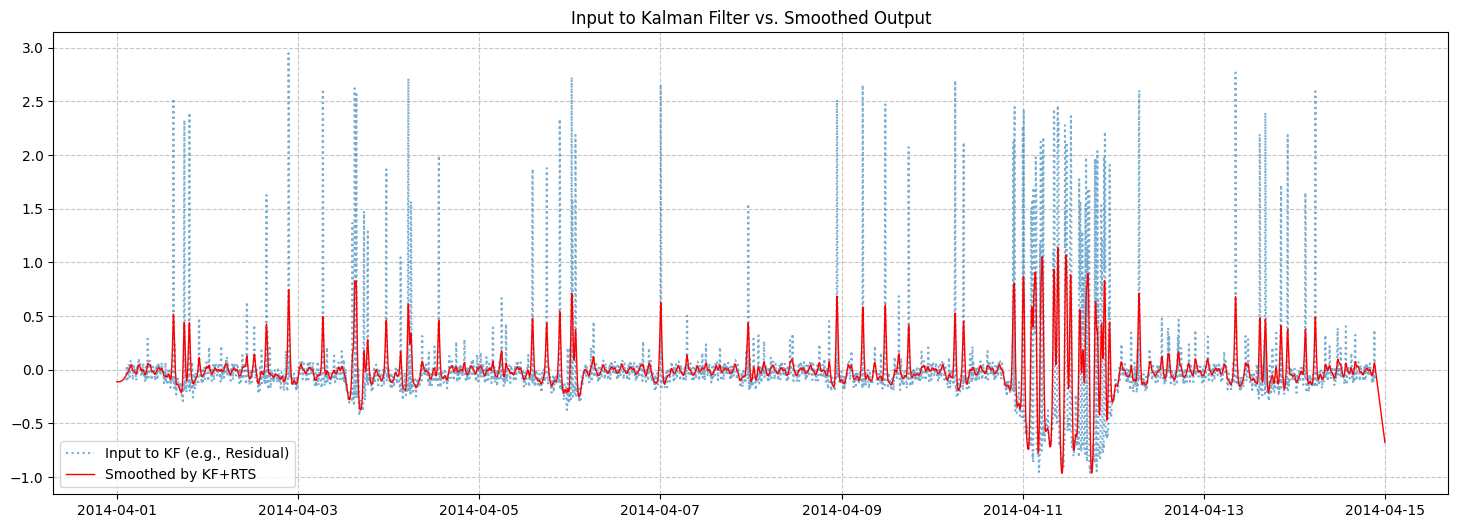

Original anomaly labels reindexed to match KF output timeline.
Shape of time_series_for_lstm_raw: (4032, 1)
Shape of true_labels_for_evaluation_aligned: (4032,)
Sum of anomalies in aligned labels: 403
--- KF & RTS Smoothing and Label Alignment Complete ---


In [68]:
print(f"\n--- Applying Kalman Filter & RTS Smoothing, Aligning Labels ---")
df_kf_smoothed = None
time_series_for_lstm_raw = None # 将用于LSTM的最终数值序列
true_labels_for_evaluation_aligned = None # 与LSTM输入对齐的标签

if series_for_kf is not None and not series_for_kf.isnull().all():
    # 获取原始数据（或分解后选择的序列）的频率
    # 对于NAB这个数据集，通常是5分钟。如果data_df.index有freqstr，可以用它。
    # 否则，我们根据数据特性指定，例如 "5min"。
    # 你在函数调用示例中用了 "300s"，也就是5分钟。
    kf_processing_freq = "5min"

    print(f"Applying KF+RTS with resampling frequency: {kf_processing_freq}")
    df_kf_smoothed = kf_rts_fill_revised(
        ts_values_input=series_for_kf.to_numpy(),
        ts_index_input=series_for_kf.index,
        freq=kf_processing_freq,
        Q_kf=1e-3,      # 过程噪声，可以调整 (你的示例是1e-4)
        R_kf=0.04,      # 测量噪声，可以调整 (你的示例是0.05)
        init_var_kf=1.0 # 初始协方差 (你的示例是10)
    )

    if not df_kf_smoothed.empty:
        print("Kalman filtering and RTS smoothing complete.")
        print("Smoothed data head:\n", df_kf_smoothed.head())

        # 可选：绘制原始序列 vs 平滑后序列
        plt.figure(figsize=(18, 6))
        plt.plot(series_for_kf.index, series_for_kf, label='Input to KF (e.g., Residual)', alpha=0.6, linestyle=':')
        plt.plot(df_kf_smoothed.index, df_kf_smoothed['value_smoothed'], label='Smoothed by KF+RTS', color='red', linewidth=1)
        plt.title("Input to Kalman Filter vs. Smoothed Output")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

        # 更新将用于LSTM的序列
        time_series_for_lstm_raw = df_kf_smoothed['value_smoothed'].values.reshape(-1, 1)

        # ---- 关键：对齐真实异常标签 ----
        # 原始的真实标签 data_df['is_anomaly'] 是与 data_df.index 对齐的
        # 我们需要将这些标签与 df_kf_smoothed.index (即经过KF处理和可能重采样后的时间轴) 对齐
        if 'is_anomaly' in data_df.columns:
            original_anomaly_labels_series = pd.Series(data_df['is_anomaly'].values, index=data_df.index)

            # 使用 reindex 将原始标签对齐到新的时间戳索引上
            # method='nearest' 会找到最近的原始标签；对于缺失很多的情况，可能需要更复杂的策略
            # method='ffill' 或 'bfill' 也可以考虑，但对于0/1标签可能不理想
            # 如果KF的freq与原始数据一致且没有引入新的时间点，对齐会比较直接
            aligned_labels = original_anomaly_labels_series.reindex(df_kf_smoothed.index, method='nearest')

            # reindex后可能因为新的时间点而产生NaN，用0（正常）填充
            aligned_labels_filled = aligned_labels.fillna(0).astype(int)

            true_labels_for_evaluation_aligned = aligned_labels_filled.to_numpy()

            print(f"Original anomaly labels reindexed to match KF output timeline.")
            print(f"Shape of time_series_for_lstm_raw: {time_series_for_lstm_raw.shape}")
            print(f"Shape of true_labels_for_evaluation_aligned: {true_labels_for_evaluation_aligned.shape}")
            if true_labels_for_evaluation_aligned is not None:
                 print(f"Sum of anomalies in aligned labels: {true_labels_for_evaluation_aligned.sum()}")
        else:
            print("Warning: 'is_anomaly' column not found in original data_df for alignment.")
            true_labels_for_evaluation_aligned = np.zeros(len(time_series_for_lstm_raw)) # Fallback

    else:
        print("Kalman filtering returned an empty DataFrame. Using original series (if available) or stopping.")
        # 如果KF失败，可能需要回退到使用 series_for_kf 或 data_df['value']
        if series_for_kf is not None:
            time_series_for_lstm_raw = series_for_kf.dropna().values.reshape(-1,1) # 简单移除NaN作为回退
            # 标签也需要对应处理，这里简化
            if 'is_anomaly' in data_df.columns:
                 true_labels_for_evaluation_aligned = data_df['is_anomaly'].loc[series_for_kf.dropna().index].values
            else:
                 true_labels_for_evaluation_aligned = np.zeros(len(time_series_for_lstm_raw))
            print("Fallback: Using original (or decomposed) series for LSTM input after dropping NaNs.")
        else:
            time_series_for_lstm_raw = None


else:
    print("Input series for Kalman filter (series_for_kf) is not available. Skipping KF and subsequent steps.")

print(f"--- KF & RTS Smoothing and Label Alignment Complete ---")

In [69]:
print(f"\n--- LSTM Data Preprocessing (on KF Output) ---")
# 确保 time_series_for_lstm_raw 和 true_labels_for_evaluation_aligned 已成功生成
if time_series_for_lstm_raw is not None and true_labels_for_evaluation_aligned is not None and len(time_series_for_lstm_raw) > 0:
    scaler = MinMaxScaler(feature_range=(-1, 1))
    time_series_scaled = scaler.fit_transform(time_series_for_lstm_raw) # 使用KF平滑后的数据
    print(f"Data scaled. Shape: {time_series_scaled.shape}")

    SEQUENCE_LENGTH = 30

    def create_sequences_colab(input_data, sequence_length): # 函数定义不变
        sequences = []
        for i in range(len(input_data) - sequence_length + 1):
            seq = input_data[i:(i + sequence_length)]
            sequences.append(seq)
        return np.array(sequences)

    X_sequences = create_sequences_colab(time_series_scaled, SEQUENCE_LENGTH)
    X_tensor = torch.tensor(X_sequences, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(X_sequences, dtype=torch.float32).to(device)

    print(f"Created sequences. X_tensor shape: {X_tensor.shape}, y_tensor shape: {y_tensor.shape}")

    BATCH_SIZE = 32
    dataset = TensorDataset(X_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    print(f"DataLoader created with batch size {BATCH_SIZE}.")

    # ---- 更新用于评估的真实标签 ----
    # 之前的 true_labels_for_evaluation 是整个序列的标签
    # LSTM的输出是序列，异常分数也是针对序列的，然后映射回点
    # 在评估时，我们需要将模型对序列的预测（通常映射到序列的最后一个点）
    # 与该点的真实标签进行比较。
    # true_labels_for_evaluation_aligned 已经是与 time_series_for_lstm_raw (及其缩放版本) 的每个点对齐的。
    # 在计算异常分数并映射回点之后，我们将使用这个对齐的标签。
    # 我们需要确保在评估步骤（单元格7）中使用的 eval_true_labels 来源于这个对齐后的版本。
    # 在单元格6中，anomaly_scores会根据SEQUENCE_LENGTH与原始长度对齐，所以
    # true_labels_for_evaluation_aligned 应该是我们最终在单元格7中进行比较的基准。

else:
    print("Skipping LSTM data preprocessing as 'time_series_for_lstm_raw' or 'true_labels_for_evaluation_aligned' is not available or empty.")

print(f"--- LSTM Data Preprocessing Complete ---")


--- LSTM Data Preprocessing (on KF Output) ---
Data scaled. Shape: (4032, 1)
Created sequences. X_tensor shape: torch.Size([4003, 30, 1]), y_tensor shape: torch.Size([4003, 30, 1])
DataLoader created with batch size 32.
--- LSTM Data Preprocessing Complete ---


In [70]:
print(f"\n--- LSTM Autoencoder Model Definition ---")
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super(LSTMAutoencoder, self).__init__()
        self.encoder_lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.decoder_lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim, # 可以选择不同的解码器隐藏层大小
            num_layers=num_layers,
            batch_first=True
        )
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        encoder_outputs, (hidden, cell) = self.encoder_lstm(x)
        # 使用编码器的输出（所有时间步）作为解码器的输入
        decoder_outputs, _ = self.decoder_lstm(encoder_outputs, (hidden, cell))
        reconstructed_x = self.output_layer(decoder_outputs)
        return reconstructed_x

# 模型参数
INPUT_DIM = 1  # 单变量时间序列
HIDDEN_DIM = 64 # LSTM隐藏单元数量 (可调)
NUM_LAYERS = 2  # LSTM层数 (可调)

if 'X_tensor' in locals(): # 确保模型可以被实例化
    model = LSTMAutoencoder(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)
    print(model)
    print(f"Model instantiated and moved to device: {next(model.parameters()).device}")
else:
    print("Cannot instantiate model as X_tensor is not available.")
print(f"--- Model Definition Complete ---")


--- LSTM Autoencoder Model Definition ---
LSTMAutoencoder(
  (encoder_lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (decoder_lstm): LSTM(64, 64, num_layers=2, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)
Model instantiated and moved to device: cuda:0
--- Model Definition Complete ---



--- Model Training ---
Starting training for 30 epochs...
Epoch [5/30], Loss: 0.000023
Epoch [10/30], Loss: 0.000007
Epoch [15/30], Loss: 0.000005
Epoch [20/30], Loss: 0.000010
Epoch [25/30], Loss: 0.000012
Epoch [30/30], Loss: 0.000009
Training finished.


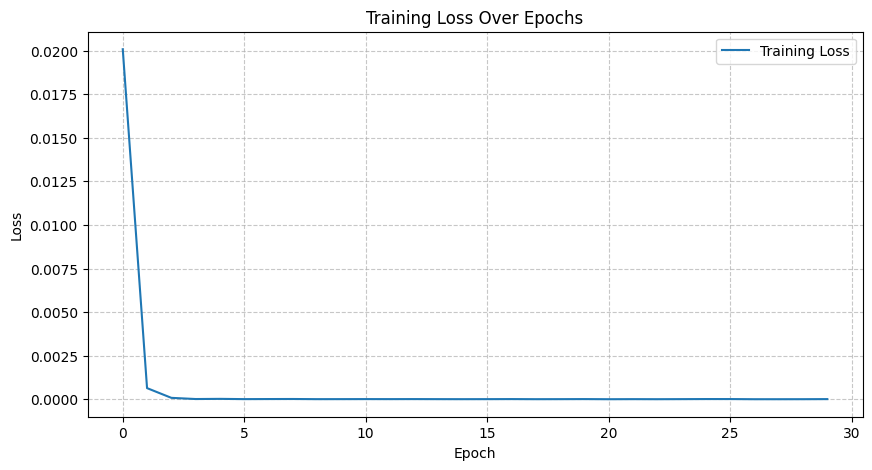

--- Model Training Complete ---


In [71]:
print(f"\n--- Model Training ---")
if 'model' in locals() and 'dataloader' in locals(): # 确保模型和数据加载器已准备好
    NUM_EPOCHS = 30  # 可根据需要调整
    LEARNING_RATE = 0.001

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) # 之前本地环境出错的地方

    history = {'train_loss': []}
    print(f"Starting training for {NUM_EPOCHS} epochs...")
    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_loss = 0
        for seq_in, seq_target in dataloader:
            # 数据已经在创建 DataLoader 时移到了 device
            # seq_in, seq_target = seq_in.to(device), seq_target.to(device)

            optimizer.zero_grad()
            seq_pred = model(seq_in)
            loss = criterion(seq_pred, seq_target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(dataloader)
        history['train_loss'].append(avg_epoch_loss)
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {avg_epoch_loss:.6f}")
    print("Training finished.")

    # 可视化训练损失
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Training Loss')
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Skipping model training as model or dataloader is not available.")
print(f"--- Model Training Complete ---")

In [72]:
print(f"\n--- Anomaly Score Calculation (on KF Output) ---")
# 确保模型和 X_tensor (来自KF平滑后的数据) 已准备好
if 'model' in locals() and 'X_tensor' in locals() and 'criterion' in locals() and 'SEQUENCE_LENGTH' in locals() and 'time_series_scaled' in locals() :
    model.eval()
    reconstruction_errors_per_sequence = []

    # 使用之前创建的 X_tensor (已经是 .to(device) 的)
    # 为了逐个序列计算误差，我们可以创建一个临时的 DataLoader 或直接遍历 X_tensor
    # temp_dataset_for_eval_kf = TensorDataset(X_tensor, X_tensor) # 目标也是X_tensor
    # temp_dataloader_for_eval_kf = DataLoader(temp_dataset_for_eval_kf, batch_size=1, shuffle=False)

    with torch.no_grad():
        # for seq_true_batch, _ in temp_dataloader_for_eval_kf: # seq_true_batch is already on device
        for i in range(X_tensor.size(0)): # 遍历每个序列
            seq_true_single = X_tensor[i:i+1] # 获取单个序列，保持batch维度
            seq_pred_single = model(seq_true_single)
            error = criterion(seq_pred_single, seq_true_single).item()
            reconstruction_errors_per_sequence.append(error)

    reconstruction_errors_per_sequence = np.array(reconstruction_errors_per_sequence)
    print(f"Calculated reconstruction errors for {len(reconstruction_errors_per_sequence)} sequences (from KF output).")

    # 将序列的重构误差映射回原始时间序列的每个点 (相对于KF处理后的时间轴)
    anomaly_scores_kf = np.full(len(time_series_scaled), np.nan)
    for i in range(len(reconstruction_errors_per_sequence)):
        anomaly_scores_kf[i + SEQUENCE_LENGTH - 1] = reconstruction_errors_per_sequence[i]

    first_valid_score_idx_kf = np.where(~np.isnan(anomaly_scores_kf))[0]
    if len(first_valid_score_idx_kf) > 0:
        anomaly_scores_kf[:first_valid_score_idx_kf[0]] = anomaly_scores_kf[first_valid_score_idx_kf[0]]
    else:
        anomaly_scores_kf[:] = 0

    print("Anomaly scores (from KF output) mapped to respective time points.")
else:
    print("Skipping anomaly score calculation as prerequisites are not met.")
    anomaly_scores_kf = None # 确保定义了，即使是None

print(f"--- Anomaly Score Calculation (on KF Output) Complete ---")


--- Anomaly Score Calculation (on KF Output) ---
Calculated reconstruction errors for 4003 sequences (from KF output).
Anomaly scores (from KF output) mapped to respective time points.
--- Anomaly Score Calculation (on KF Output) Complete ---


In [73]:
print(f"\n--- Thresholding and Evaluation (with KF Preprocessing) ---")
# 确保 anomaly_scores_kf 和 true_labels_for_evaluation_aligned 已准备好
if anomaly_scores_kf is not None and true_labels_for_evaluation_aligned is not None:
    valid_indices_for_eval_kf = ~np.isnan(anomaly_scores_kf) # 基于 anomaly_scores_kf 的有效索引

    # 确保 true_labels_for_evaluation_aligned 和 anomaly_scores_kf 的长度一致
    # 它们都应该与 KF 处理后的序列长度相同
    if len(anomaly_scores_kf) == len(true_labels_for_evaluation_aligned):
        eval_scores_kf = anomaly_scores_kf[valid_indices_for_eval_kf]
        eval_true_labels_kf = true_labels_for_evaluation_aligned[valid_indices_for_eval_kf]

        if len(eval_scores_kf) > 0 and len(eval_true_labels_kf) > 0:
            threshold_kf = np.quantile(eval_scores_kf, 0.95)
            print(f"Anomaly threshold (on KF scores, 95th percentile): {threshold_kf:.6f}")

            predicted_anomalies_bool_kf = eval_scores_kf > threshold_kf
            predicted_anomalies_int_kf = predicted_anomalies_bool_kf.astype(int)

            precision, recall, f1, _ = precision_recall_fscore_support(eval_true_labels_kf, predicted_anomalies_int_kf, average='binary', zero_division=0)
            cm = confusion_matrix(eval_true_labels_kf, predicted_anomalies_int_kf)

            print(f"Evaluation Results (on KF preprocessed data):")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall:    {recall:.4f}")
            print(f"  F1-Score:  {f1:.4f}")
            print(f"  Confusion Matrix:\n{cm}")
        else:
            print("Not enough data for evaluation after NaN removal (KF scores).")
    else:
        print(f"Error: Length mismatch between anomaly_scores_kf ({len(anomaly_scores_kf)}) and true_labels_for_evaluation_aligned ({len(true_labels_for_evaluation_aligned)}). Cannot evaluate.")
else:
    print("Skipping thresholding and evaluation as 'anomaly_scores_kf' or 'true_labels_for_evaluation_aligned' is not available.")
print(f"--- Thresholding and Evaluation (with KF Preprocessing) Complete ---")


--- Thresholding and Evaluation (with KF Preprocessing) ---
Anomaly threshold (on KF scores, 95th percentile): 0.000012
Evaluation Results (on KF preprocessed data):
  Precision: 0.9356
  Recall:    0.4690
  F1-Score:  0.6248
  Confusion Matrix:
[[3616   13]
 [ 214  189]]
--- Thresholding and Evaluation (with KF Preprocessing) Complete ---



--- Final Visualization (with KF Preprocessing) ---


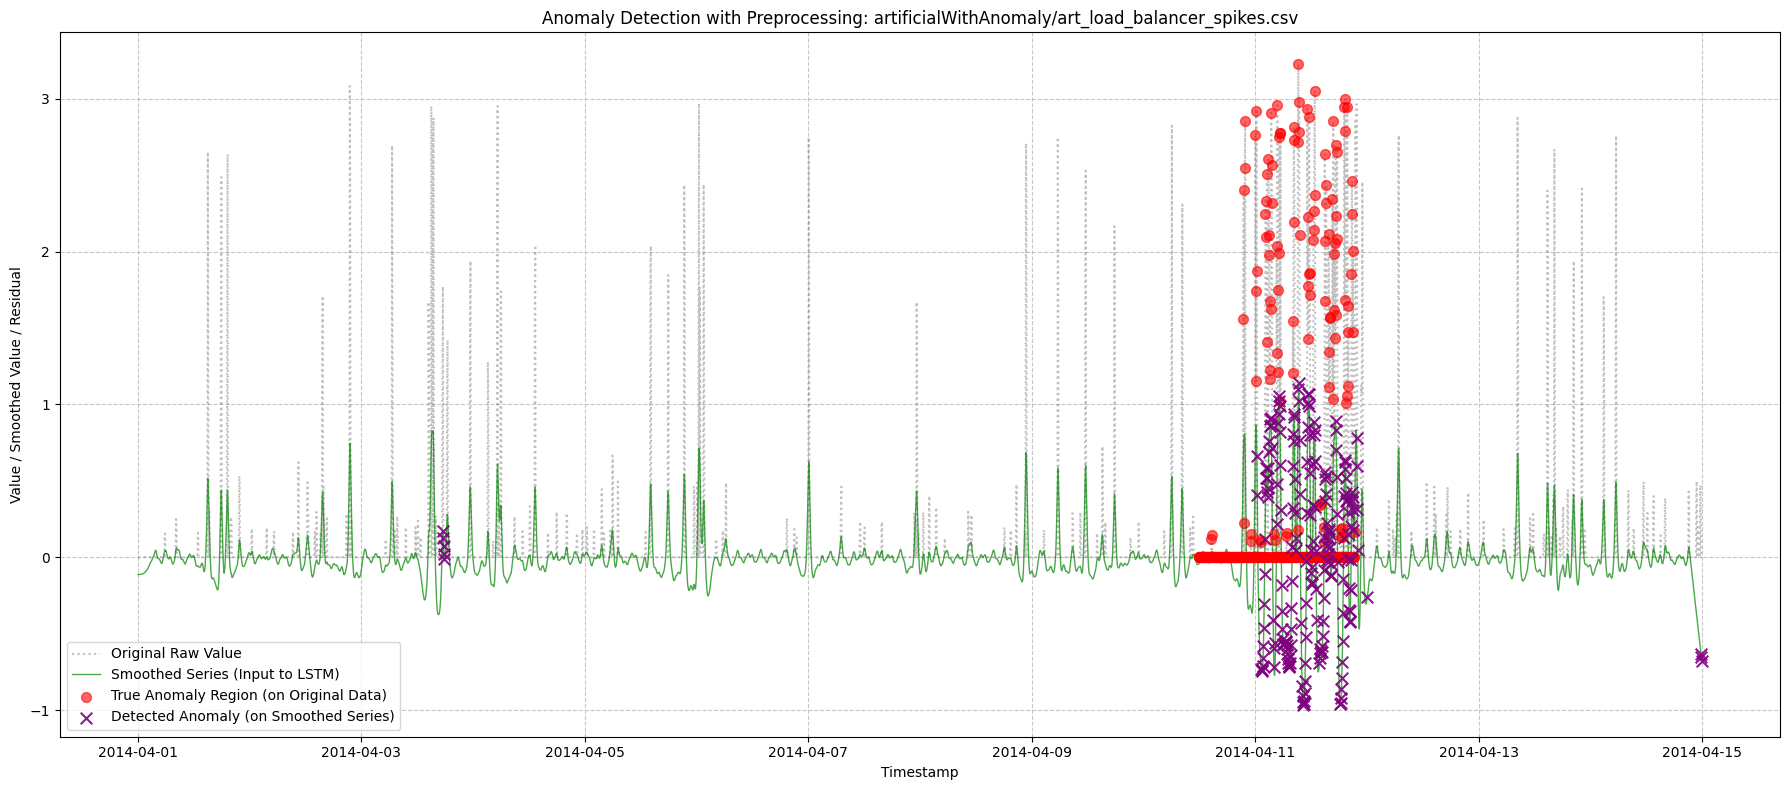

--- Visualization (with KF Preprocessing) Complete ---


In [74]:
print(f"\n--- Final Visualization (with KF Preprocessing) ---")
# 确保所有绘图所需数据都存在
if ('data_df' in locals() and data_df is not None and
    'df_kf_smoothed' in locals() and df_kf_smoothed is not None and
    'anomaly_scores_kf' in locals() and anomaly_scores_kf is not None and
    'threshold_kf' in locals() and
    'scaler' in locals() and # scaler 是用于 time_series_for_lstm_raw 的
    'true_labels_for_evaluation_aligned' in locals() and true_labels_for_evaluation_aligned is not None):

    plt.figure(figsize=(18, 8))

    # 1. 绘制原始数据 (逆归一化前的原始值)
    plt.plot(data_df.index, data_df['value'], label='Original Raw Value', color='gray', alpha=0.5, linestyle=':')

    # 2. 绘制经过KF平滑后的数据 (用于LSTM输入的数据，需要逆归一化)
    # scaler 是基于 time_series_for_lstm_raw (即 df_kf_smoothed['value_smoothed']) 训练的
    # time_series_scaled 是 df_kf_smoothed['value_smoothed'] 归一化后的结果
    # 我们需要逆归一化 time_series_scaled 来得到与原始尺度可比较的平滑序列
    # 或者，如果 scaler 只用于 LSTM 输入，而 KF 输出已经是某种有意义的尺度（如残差），则可以直接绘制 KF 输出

    # 绘制KF平滑后的序列（它本身是LSTM的输入，例如平滑后的残差）
    # 这个序列的尺度可能与原始值不同，取决于它是平滑后的趋势、残差还是原始值
    # 为了清晰，我们主要关注原始数据和在其上标记的异常
    plt.plot(df_kf_smoothed.index, df_kf_smoothed['value_smoothed'], label='Smoothed Series (Input to LSTM)', color='green', linewidth=1, alpha=0.7)


    # 3. 标记真实异常区域 (基于原始 data_df 和其 'is_anomaly' 列)
    true_anomalies_plot_df = data_df[data_df['is_anomaly'] == 1]
    if not true_anomalies_plot_df.empty:
        plt.scatter(true_anomalies_plot_df.index,
                    true_anomalies_plot_df['value'],
                    color='red', label='True Anomaly Region (on Original Data)', marker='o', s=50, alpha=0.6, zorder=3)

    # 4. 标记模型检测到的异常点
    # predicted_anomalies_on_kf_timeline 是在 df_kf_smoothed 的时间轴上的预测 (0 或 1)
    predicted_anomalies_on_kf_timeline = np.zeros_like(anomaly_scores_kf, dtype=int)
    if 'predicted_anomalies_bool_kf' in locals() and 'valid_indices_for_eval_kf' in locals(): # 确保已计算
        predicted_anomalies_on_kf_timeline[valid_indices_for_eval_kf] = predicted_anomalies_bool_kf.astype(int)

    # 获取检测到异常的时间戳 (这些时间戳来自 df_kf_smoothed.index)
    detected_anomaly_timestamps = df_kf_smoothed.index[predicted_anomalies_on_kf_timeline == 1]

    if len(detected_anomaly_timestamps) > 0:
        # 在原始数据图上标记这些时间点对应的原始值
        # 我们需要从 data_df 中找到与 detected_anomaly_timestamps 最接近的原始值
        # 为了简化，如果时间戳能直接匹配就标记，或者标记在平滑序列上

        # 标记在平滑序列上的检测结果
        plt.scatter(detected_anomaly_timestamps,
                    df_kf_smoothed['value_smoothed'][predicted_anomalies_on_kf_timeline == 1],
                    color='purple', label='Detected Anomaly (on Smoothed Series)', marker='x', s=70, alpha=0.9, zorder=4)

        # (可选) 如果想标记在原始数据上，需要处理时间戳对齐
        # original_values_at_detected_anomalies = data_df['value'].reindex(detected_anomaly_timestamps, method='nearest')
        # plt.scatter(detected_anomaly_timestamps,
        #             original_values_at_detected_anomalies,
        #             color='magenta', label='Detected Anomaly (Nearest Original Value)', marker='P', s=60, alpha=0.8, zorder=5)


    plt.title(f"Anomaly Detection with Preprocessing: {JSON_KEY_FOR_LABELS}")
    plt.xlabel("Timestamp")
    plt.ylabel("Value / Smoothed Value / Residual")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping final visualization as prerequisites are not met.")
print(f"--- Visualization (with KF Preprocessing) Complete ---")